# What one sentence can Meera sign, with its evidence, its branch, its caveat and its ask?

**Week 1, Monday, chapter 6 of 6.** Meera will not read the day's notebooks. She needs the answer,
the evidence and the limit of the evidence in the time it takes to read one sentence, and
marketing will read the same sentence looking for the weakest number in it.

**Who needs the answer.** Meera signs the sentence, Kavya reviews it first, and the marketing
lead reads it for the number to attack. A sentence that says "70 percent of customers are lost"
either panics the room or hands marketing an easy rebuttal, and the team loses the trust the
week depends on.

**The questions on the way.**

1. Which form carries the decision in the time Meera has?
2. What does the first draft of the sentence say?
3. How many of the 16 one-time buyers are really lost?
4. Does counting forward from each order find the same buyers too recent to judge?
5. What does the sentence Meera signs say?

The metric at stake is the repeat picture: who came back, who has not, and who has not had time
to. Klarna reported that its AI assistant handled two-thirds of customer-service chats in its
first month (Klarna, 27 February 2024); fifteen months later its chief executive said the focus
on cost had lowered quality (Fortune, 9 May 2025). Meera's sentence carries a caveat so that
one window's number is not taken as the verdict. Section 5 of the retail dossier,
`study-notes/C2_W01_D01_domain_retail_STUDENT.md`, covers retention and cohorts, and its section
8 tells Klarna's case in full.

Chapter 5 chose frequency first: 16 of 23 customers bought once and 7 came back, and two 10
percent lifts make 21 percent where the slide said 20. This chapter turns that into the sentence
and tests the one number in it most likely to be misread.

> **Kavya's review.** One sentence, four parts in this order: the evidence with its window, the
> branch, what the window cannot show, and what happens to the Rs 12 crore.

**Setup.** The first cell finds the shared helper, loads the 30 orders from `../data/`, applies
chapter 1's `int()` fix, and groups each customer's order dates.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

ORDERS = kit.load_records()

from datetime import date
for order in ORDERS:
    order["amount"] = int(order["amount"])     # chapter 1's fix for an amount stored as text
start = date.fromisoformat(min(o["order_date"] for o in ORDERS))
end = date.fromisoformat(max(o["order_date"] for o in ORDERS))
by_customer = {}
for order in ORDERS:
    by_customer.setdefault(order["customer_id"], []).append(date.fromisoformat(order["order_date"]))
customers = len(by_customer)
once_ids = [cid for cid, days in by_customer.items() if len(days) == 1]
print(f"{len(ORDERS)} orders from {start} to {end}, {(end - start).days + 1} days; {customers} customers, {len(once_ids)} bought once")

30 orders from 2026-07-01 to 2026-09-26, 88 days; 23 customers, 16 bought once


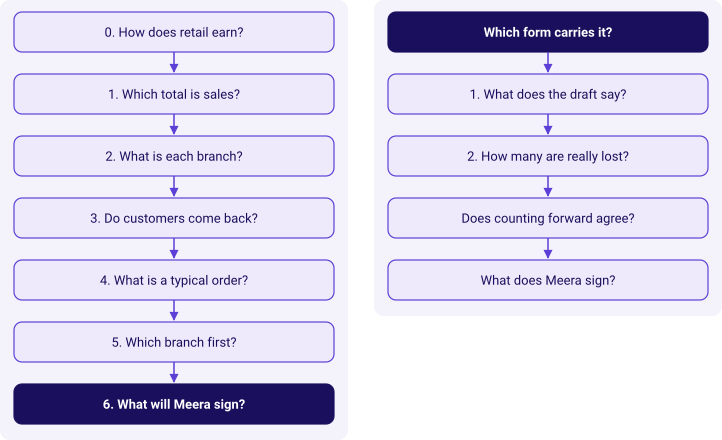

In [2]:
kit.side_by_side(
    kit.vflow(['0. How does retail earn?', '1. Which total is sales?', '2. What is each branch?', '3. Do customers come back?', '4. What is a typical order?', '5. Which branch first?', '6. What will Meera sign?'], lit=6, show=False),
    kit.vflow(['Which form carries it?', '1. What does the draft say?', '2. How many are really lost?', 'Does counting forward agree?', 'What does Meera sign?'], lit=0, show=False),
)

## Which form carries the decision in the time Meera has?

There are four ways to hand Meera the answer, sized in the reader's time and in what can go
wrong.

| Option | Her reading time | The decision it carries | How it gets misread |
|---|---|---|---|
| A. One number: "orders per customer, 1.30" | two seconds | It carries none, and she has to supply it. | She reads it as good or bad news with no benchmark. |
| B. The tree as a table of every leaf | a minute or more | It carries none, and she draws the conclusion. | She picks the number that suits the room. |
| C. One sentence: evidence, branch, caveat, the ask | about twenty seconds | It carries the call: open frequency and hold the budget until Tuesday. | It is misread only if a number in it is, which the trap below tests. |
| D. A dashboard refreshed every week | weeks to build | It carries whatever she looks at. | A chart with no denominator misleads her. |

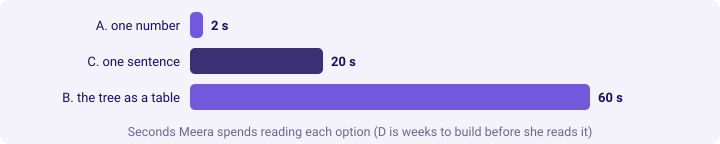

In [3]:
reading = [("A. one number", 2), ("C. one sentence", 20), ("B. the tree as a table", 60)]
kit.bars(reading, fmt=lambda v: f"{v} s", lit=(1,),
         title="Seconds Meera spends reading each option (D is weeks to build before she reads it)")
kit.check("the sentence is the one option that carries a decision inside half a minute",
          [n for n, t in reading if t <= 30 and n.startswith("C")] == ["C. one sentence"])

**The best-fit call.** C: one sentence, read in about twenty seconds, is the only option that
carries a decision and its limit together. **What would change it:** when the question becomes
weekly, as it does when Meera's chief of staff asks for the leadership deck in Week 2, D earns
its build cost, with C as its headline.

## 1. What does the first draft of the sentence say?

Every number in the sentence comes from a variable, so the sentence cannot drift from the work.
The draft carries the evidence the chapters produced, in the four parts.

**Predict before you run.** Which part does the sentence put last?

- a) The evidence.
- b) What happens to the Rs 12 crore.
- c) The branch.
- d) The caveat.

On the 30 booked orders from 1 July to 26 September, 23 customers placed 1.30 orders each at a typical order of Rs 2,205, and 16 of them bought only once, so I would open frequency before acquisition, and since one quarter cannot show which branch moved, hold the Rs 12 crore until Tuesday's two quarters.


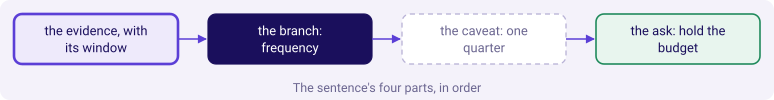

In [4]:
amounts = sorted(o["amount"] for o in ORDERS)
median = (amounts[14] + amounts[15]) / 2
per_customer = len(ORDERS) / customers
came_back = customers - len(once_ids)
draft = (f"On the {len(ORDERS)} booked orders from 1 July to 26 September, {customers} customers placed "
         f"{per_customer:.2f} orders each at a typical order of {kit.rupees(median)}, and {len(once_ids)} of "
         f"them bought only once, so I would open frequency before acquisition, and since one quarter cannot "
         f"show which branch moved, hold the Rs 12 crore until Tuesday's two quarters.")
print(draft)
kit.flow(["the evidence, with its window", "the branch: frequency", "the caveat: one quarter",
          "the ask: hold the budget"], kinds=["known", "lit", "unknown", "good"],
         title="The sentence's four parts, in order")
kit.check("the draft carries the customers, the rate and the typical order",
          str(customers) in draft and f"{per_customer:.2f}" in draft and kit.rupees(median) in draft)
kit.check("the draft ends on the budget", draft.rstrip(".").endswith("two quarters"))

**What happened.** The answer is b: the draft puts the evidence first, then the branch and the
limit, and ends on the Rs 12 crore, the ask Meera acts on. It reads 23 customers at 1.30 orders
each, a typical order of Rs 2,205, and 16 who bought only once, and that 16 is the number
marketing will reach for.

## 2. How many of the 16 one-time buyers are really lost?

A colleague tightens the draft for the slide, and the 16 becomes a percentage.

**Predict before you run.** 16 of the 23 customers bought only once in the quarter. How many of
them can you say are lost?

- a) All 16, about 70 percent of the customers.
- b) None, since every one of them might still return.
- c) Only those past the usual gap between orders.
- d) Seven, the same as those who came back.

**The plausible wrong answer.**

In [5]:
lost_share = len(once_ids) / customers
print(f"{len(once_ids)} of {customers} customers never came back: {lost_share:.0%} of customers are lost")

16 of 23 customers never came back: 70% of customers are lost


**Why it is wrong.** A customer who bought on 19 September had seven days to come back before the
extract ends. The file shows who bought once inside the window, and whether they are lost
depends on orders placed after it closes, which the file cannot show. Sent to Meera, 70 percent
churn makes retention look like an emergency on a number marketing can knock down with one
question: how long do our customers usually take to come back? The check asks that question of
the 7 who did.

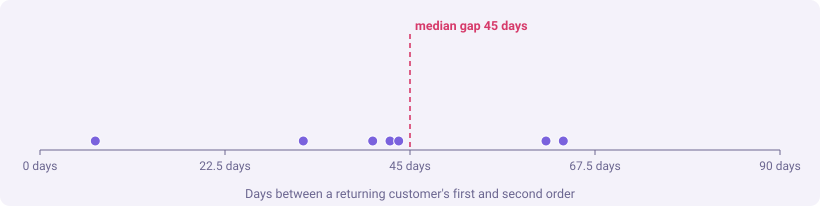

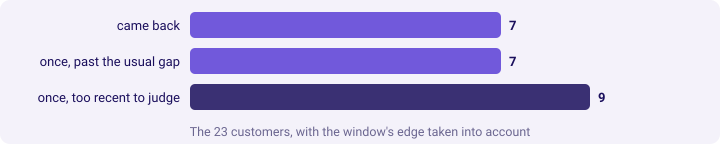

In [6]:
gaps = sorted((max(d) - min(d)).days for d in by_customer.values() if len(d) > 1)
typical_gap = gaps[len(gaps) // 2]
too_recent = [cid for cid in once_ids if (end - by_customer[cid][0]).days < typical_gap]
had_time = len(once_ids) - len(too_recent)
kit.strip(gaps, markers=[("median gap", typical_gap, "bad")], lo=0, hi=90, fmt=lambda v: f"{v:g} days",
          title="Days between a returning customer's first and second order")
kit.bars([("came back", came_back), ("once, past the usual gap", had_time),
          ("once, too recent to judge", len(too_recent))], lit=(2,),
         title="The 23 customers, with the window's edge taken into account")
kit.check("the median gap between two orders is 45 days", typical_gap == 45, gaps)
kit.check("9 of the 16 one-time buyers bought fewer than 45 days before the end", len(too_recent) == 9)
kit.check("7 came back, 7 past the usual gap, 9 are too recent",
          (came_back, had_time, len(too_recent)) == (7, 7, 9))

**What happened.** The answer is c: at most 7 of the 16 can be called lost, the ones past the
usual gap. The 7 who came back took a median of 45 days, and 9 of the 16 one-time buyers ordered
fewer than 45 days before the window ends, so they have not had a typical customer's time to
return. The file supports 7 came back, 7 past the usual gap without a second order, and 9 too
recent to judge, so "70 percent lost" becomes at most 7 of 23. The window also cuts the gap
short: a customer who took 100 days to
return could not show up in 88, so 45 days is a floor, and more of the 16 may still be on their
way back. The sentence replaces the 16 with the split.

## Does counting forward from each order find the same buyers too recent to judge?

The same split comes from the other direction: give each one-time buyer a due date, their order
date plus the typical gap, and count those whose due date falls after the window ends. The count
must match the recency route.

In [7]:
from datetime import timedelta
due_after_end = [cid for cid in once_ids if by_customer[cid][0] + timedelta(days=typical_gap) > end]
kit.table(["route", "one-time buyers too recent to judge"],
          [("days since the order, under the typical gap", len(too_recent)),
           ("due date after the window ends", len(due_after_end))],
          caption="Two routes to the same caveat")
kit.check("both routes find the same customers", set(due_after_end) == set(too_recent))

route,one-time buyers too recent to judge
"days since the order, under the typical gap",9
due date after the window ends,9


**What happened.** It does: counting forward 45 days from each order finds the same 9 buyers
whose due date falls after 26 September.

**When to switch.** Recency is the route when you report today's state; due dates are the route
when you plan follow-ups, since a due date is the day a reminder would go out. Both need the
gap, and a second quarter would show which of the 9 came back and would see returns slower than
88 days, so the caveat would shrink.

> **Kavya's review.** This is a sentence I would take into the room. It says what we know, what
> we would do, and what we would need before spending Rs 12 crore, and every number in it is one
> we can defend.

### How would you answer an interviewer who asks what one quarter says about lost customers?

**[D] You have one quarter of orders and 70 percent of customers bought once; what do you tell
the CEO?** "I tell the CEO that 70 percent bought once in this window, which is a fact, and
that it is no churn rate. Customers who came back took a median of 45 days, and 9 of the 16 one-time buyers bought
fewer than 45 days before the extract ends, so they have not had time. I would say 7 came back,
7 are past the usual gap and 9 are too recent, and add that a one-quarter window only sees short
gaps, so 45 days is a floor. Then I ask for the prior quarter before calling anyone lost."

**[F] How do you write a recommendation a stakeholder can act on?** "One sentence in four parts:
the evidence with its window and definition, the recommendation, what the evidence cannot show,
and the decision it asks for. Every number comes from the analysis without retyping, and none
can be recomputed into a different story by the person who disagrees."

**[D] When would you replace this sentence with a dashboard?** "When the question recurs on a
schedule and the definitions are settled, so the build cost is paid back every week. Until then
a sentence with its caveat is faster and harder to misread."

### Where else does the window's edge cut a metric short?

Any count of who has not done something yet is cut short at the end of the window: returns that
arrive after the window closes, renewals not yet due, orders still in transit when the extract is
taken. The fix is always
to measure how long the thing usually takes and hold back judgement on everyone who has not had
that long.

## What does the sentence Meera signs say?

"On the 30 booked orders from 1 July to 26 September, 23 customers placed 1.30 orders each at a
typical order of Rs 2,205; 7 came back, 7 are past the usual gap without a second order, and 9
bought too recently to judge, so I would open frequency before acquisition, and since one
quarter cannot show which branch moved, hold the Rs 12 crore until Tuesday's two quarters." The
cell below builds it from the variables, so no number in it can drift from the work.

- Which form carries the decision in the time Meera has? One sentence in four parts carries it,
  read in about twenty seconds.
- What does the first draft of the sentence say? It gives the evidence, the branch, the caveat
  and the ask, with 16 of 23 who bought once as its weakest number.
- How many of the 16 one-time buyers are really lost? At most 7 are, the ones past the median gap of 45 days,
  and 9 are too recent to judge.
- Does counting forward from each order find the same buyers too recent to judge? It finds the
  same 9 customers.
- What can Meera sign? She can sign the sentence above, with its evidence, its branch, its
  caveat and its ask.

In [8]:
sentence = (f"On the {len(ORDERS)} booked orders from 1 July to 26 September, {customers} customers placed "
            f"{per_customer:.2f} orders each at a typical order of {kit.rupees(median)}; {came_back} came back, "
            f"{had_time} are past the usual gap without a second order, and {len(too_recent)} bought too recently "
            f"to judge, so I would open frequency before acquisition, and since one quarter cannot show which "
            f"branch moved, hold the Rs 12 crore until Tuesday's two quarters.")
print(sentence)
print(len(sentence.split()), "words")
kit.check("the sentence splits the one-time buyers", str(len(too_recent)) in sentence and str(had_time) in sentence)
kit.check("the sentence names what one quarter cannot show", "cannot show" in sentence)
kit.check("the sentence calls nobody lost", "lost" not in sentence)
kit.table(["What we now know", "The evidence"],
          [("One-time buyers are not lost customers", "median repeat gap 45 days; 9 of 16 too recent"),
           ("The sentence has four parts in a fixed order", f"{len(sentence.split())} words, every number from a variable"),
           ("The Rs 12 crore waits for a second quarter", "a second quarter would show which branch moved")],
          caption="Chapter 6: what Meera signs")
kit.check_summary()
print("Next: the escalated case asks the same question on the delivered definition, alone.")

On the 30 booked orders from 1 July to 26 September, 23 customers placed 1.30 orders each at a typical order of Rs 2,205; 7 came back, 7 are past the usual gap without a second order, and 9 bought too recently to judge, so I would open frequency before acquisition, and since one quarter cannot show which branch moved, hold the Rs 12 crore until Tuesday's two quarters.
69 words


What we now know,The evidence
One-time buyers are not lost customers,median repeat gap 45 days; 9 of 16 too recent
The sentence has four parts in a fixed order,"69 words, every number from a variable"
The Rs 12 crore waits for a second quarter,a second quarter would show which branch moved


Next: the escalated case asks the same question on the delivered definition, alone.
